In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import arviz as az
import numpy as np


plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data
from cppp.utils import concat_log_likelihoods


## Check model diagnostics

In [2]:
# get the participant IDs from the data
participants = load_multisensory_data(base_path="../data")["participant"].unique()
participants

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


array([135033060, 173058413, 177196795, 182095555, 212056115, 330954011,
       524048600, 544725341, 644801403, 657093471, 714671738, 741917610,
       765738475, 799755310, 802096684, 879521247, 891444214, 910949717,
       918338248])

In [24]:
def load_model(participant, model_name, seed=7453):
    model = az.from_netcdf(
        f"../results/multisensory-mcmc-{participant}_1_2_{seed}_1000_2500_4_optimal_{model_name}_['prop', 'vis'].nc"
    )
    return model


summaries = []
loos = []
for participant in participants:
    # define the model names to load
    model_names = [
        "BoundedActorPointMassDynamics",
        "BoundedActor",
        "OptimalActorPointMassDynamics",
        "OptimalActor",
    ]

    # dict for model comparisons
    models = {}

    # load the models for this participant
    for model_name in model_names:
        model = load_model(participant, model_name, seed=7453)

        summary = az.summary(model)

        # if there are any rhats higher than 1.05, load another fit
        if (az.summary(model)["r_hat"] > 1.05).any():
            model = load_model(participant, model_name, seed=7454)

            summary = az.summary(model)

        model = concat_log_likelihoods(model)
        # put model into dict
        models[model_name] = model

        # add the model name and participant to the summary dataframe
        summary["model"] = model_name
        summary["participant"] = participant
        summaries.append(summary)

        loo = az.loo(model)
        loo["model"] = model_name
        loo["participant"] = participant
        loos.append({
            "participant": participant,
            "model": model_name,
            "elpd_loo": loo.elpd_loo,
            "se": loo.se,
        })

    # stack up log likelihoods for all 6 conditions into a single array for each model so that we can perform model comparison using all conditions together
    # models = {
    #     model_name: concat_log_likelihoods(model)
    #     for model_name, model in models.items()
    # }
    # comparison = az.compare(models)
    # comparison["participant"] = participant
    # comparisons.append(comparison)

/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-propri

In [25]:
df = pd.concat(summaries).reset_index().rename(columns={"index": "parameter"})
df


,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,model,participant
0,action_cost,0.000,0.000,0.000,0.000,0.000,0.000,11418.0,8141.0,1.0,BoundedActorPointMassDynamics,135033060
1,action_variability,0.093,0.001,0.091,0.095,0.000,0.000,12584.0,7885.0,1.0,BoundedActorPointMassDynamics,135033060
2,sigma_prop,2.968,0.111,2.751,3.168,0.001,0.001,11568.0,8167.0,1.0,BoundedActorPointMassDynamics,135033060
3,sigma_vis[0],4.490,0.267,4.006,4.995,0.003,0.003,11431.0,7798.0,1.0,BoundedActorPointMassDynamics,135033060
4,sigma_vis[1],11.512,0.832,9.946,13.060,0.008,0.008,10520.0,8234.0,1.0,BoundedActorPointMassDynamics,135033060
...,...,...,...,...,...,...,...,...,...,...,...,...
375,action_cost,0.395,0.296,0.000,0.924,0.003,0.003,6023.0,3589.0,1.0,OptimalActor,918338248
376,action_variability,0.685,0.014,0.659,0.711,0.000,0.000,9574.0,6920.0,1.0,OptimalActor,918338248
377,sigma_prop,2.559,0.107,2.363,2.762,0.001,0.001,8968.0,6519.0,1.0,OptimalActor,918338248
378,sigma_vis[0],4.450,0.313,3.876,5.029,0.003,0.003,9168.0,6438.0,1.0,OptimalActor,918338248


In [28]:
loo_df = pd.DataFrame(loos)
loo_df

,participant,model,elpd_loo,se
0,135033060,BoundedActorPointMassDynamics,-8193.402954,243.099395
1,135033060,BoundedActor,-9124.143646,251.669864
2,135033060,OptimalActorPointMassDynamics,-10355.249527,338.177719
3,135033060,OptimalActor,-12172.486664,404.760290
4,173058413,BoundedActorPointMassDynamics,-17071.664032,197.505934
...,...,...,...,...
71,910949717,OptimalActor,-14400.543274,183.209875
72,918338248,BoundedActorPointMassDynamics,-15439.232513,149.414992
73,918338248,BoundedActor,-15493.032837,125.690226
74,918338248,OptimalActorPointMassDynamics,-15454.142548,160.694510


In [ ]:
# comparison_df = comparison_df.reset_index().rename(columns={"index": "model"})

short_model_name = {
    "BoundedActorPointMassDynamics": "Point-Mass with cost",
    "BoundedActor":                  "Velocity with cost",
    "OptimalActorPointMassDynamics": "Point-Mass without cost",
    "OptimalActor":                  "Velocity without cost",
}
loo_df["model_short"] = loo_df["model"].map(short_model_name)

model_order = ["Point-Mass with cost", "Velocity with cost", "Point-Mass without cost", "Velocity without cost"]
palette     = dict(zip(model_order, sns.color_palette("colorblind", 4)))

/tmp/ipykernel_2754348/1181268450.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


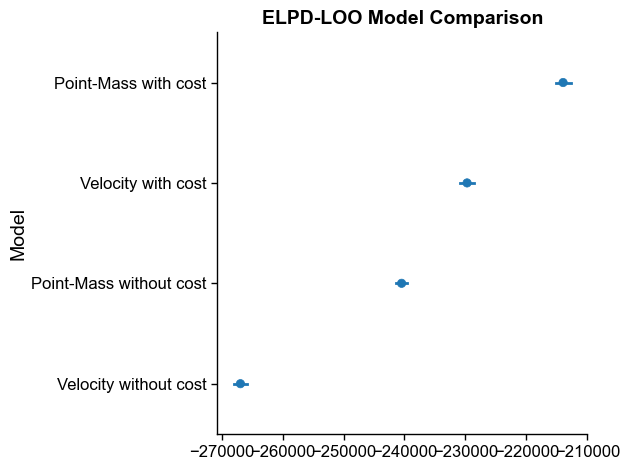

In [38]:
group_stats = (
    loo_df.groupby("model_short")
    .apply(lambda x: pd.Series({
        "elpd_loo_sum": x["elpd_loo"].sum(),
        "se_sum": np.sqrt((x["se"] ** 2).sum()),
    }))
    .reindex(model_order)
    .reset_index()
)

group_stats["elpd_low"] = group_stats["elpd_loo_sum"] - group_stats["se_sum"]
group_stats["elpd_high"] = group_stats["elpd_loo_sum"] + group_stats["se_sum"]

g = (so.Plot(group_stats, y="model_short", x="elpd_loo_sum")
      .add(so.Dot())
      .add(so.Range(), xmin="elpd_low", xmax="elpd_high")
      # .add(so.Dot(pointsize=2), so.Jitter())
      .scale(y=so.Nominal(order=model_order))
      .label(x="", y="Model", title="ELPD-LOO Model Comparison")
      .show()
)

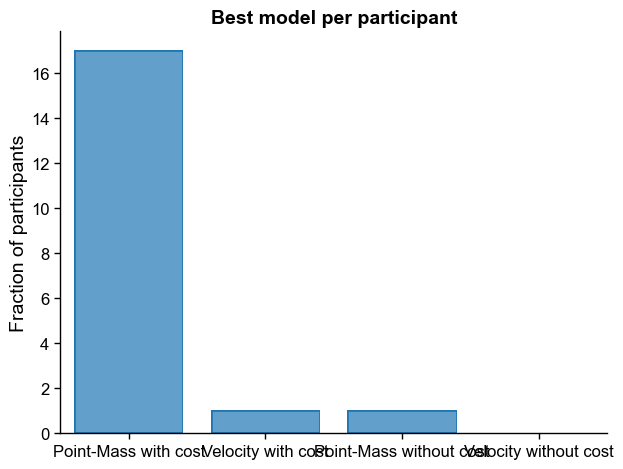

In [41]:
best_per_participant = (
    loo_df.loc[loo_df.groupby("participant")["elpd_loo"].idxmax(), "model_short"]
)

win_counts = (
    best_per_participant.value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts.columns = ["model_short", "wins"]
win_counts["n_participants"] = win_counts["wins"] 

(
    so.Plot(win_counts, x="model_short", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal(order=model_order))
    .label(x="", y="Fraction of participants", title="Best model per participant")
    .show()
)

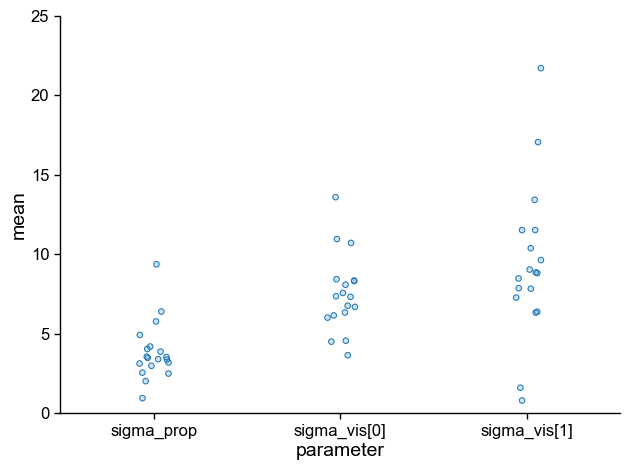

In [ ]:
g = (
    so.Plot(
        df[
            (df["model"] == "BoundedActorPointMassDynamics")
            & (df["parameter"].isin(["sigma_prop", "sigma_vis[0]", "sigma_vis[1]"]))
        ],
        x="parameter",
        y="mean",
        # color="participant",
    )
    .add(so.Dots(), so.Jitter())
    # .add(so.Line(), group="participant")
    .limit(y=(0, 25.))
    # .scale(color=so.Nominal())
    # .facet(col="parameter")
    # .share(y=False)
)
g.show()